In [1]:
import BESplotting as bp

import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
import my_funcs as mf
import numpy as np
import pyuda
client = pyuda.Client()
import sys

%matplotlib widget

kk_cz couldnt be imported
dd couldnt be imported


In [2]:
def rolling(arr, w):
    return np.convolve(arr, np.ones(w), mode='same') / w

In [3]:
shotns = [51704, 51705, 51706, 51709, 51710, 51711, 51712, 51713, 51691]
fuels = [
    '/xdc/flow/s/hfs_mid_u02', 
    '/xdc/flow/s/lfsv_bot_l03',
    '/xdc/flow/s/lfsv_top_u11',
    '/xdc/flow/s/lfsd_bot_l0506',
    '/xdc/flow/s/lfsd_top_u0506',
]

boo =    [ True, False,  True,  True, False, False, False, False, False]
puffs = [0.23, 0.35, 0.47, 0.59, 0.71]

time = np.zeros((len(shotns), 6090)) # length of time, or at least it should be
emMax = np.zeros((len(shotns), 6090))
emMaxR = np.zeros((len(shotns), 6090))
n0Max = np.zeros((len(shotns), 6090))
n0MaxR = np.zeros((len(shotns), 6090))


for i, shotn in enumerate(shotns):
    
    resultsFile = f'/home/sthoma/Documents/Results/rba/{shotn}/rba_results_neutral.npz'
    results = np.load(resultsFile)
    
    time[i] = results['time']
    emMax[i] = results['emMax']
    emMaxR[i] = results['emMaxR']
    n0Max[i] = results['neutralMax']
    n0MaxR[i] = results['neutralMaxR']

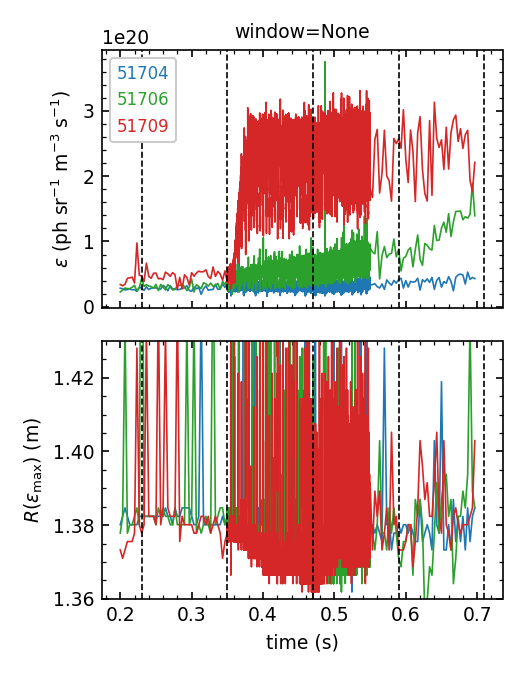

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        ax[0].plot(time[i], emMax[i], c=f'C{i}', lw=0.8, label=shotn)
        ax[1].plot(time[i], emMaxR[i], c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$\\epsilon$ (ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9)
ax[0].set_title('window=None', fontsize=9)

ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(\\epsilon_\\mathrm{max})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.43])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

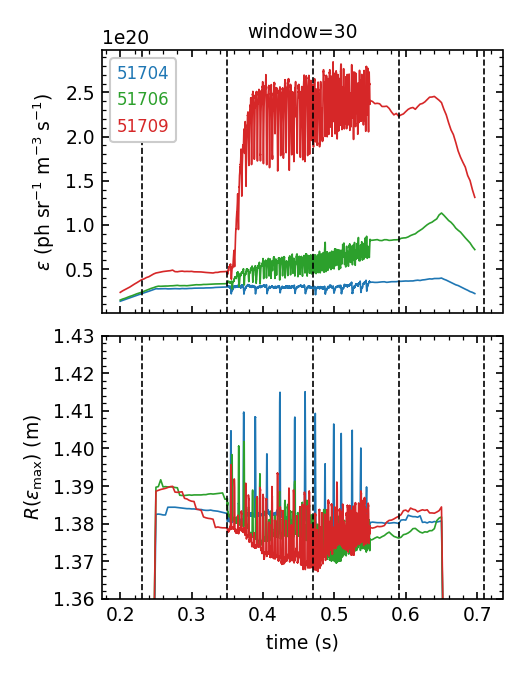

In [5]:
w = 30
emMaxAverage = np.zeros_like(emMax)
emMaxRAverage = np.zeros_like(emMaxR)
for i in range(0, len(shotns)):
    emMaxAverage[i] = rolling(emMax[i], w)
    emMaxRAverage[i] = rolling(emMaxR[i], w)
    

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        ax[0].plot(time[i], emMaxAverage[i], c=f'C{i}', lw=0.8, label=shotn)
        ax[1].plot(time[i], emMaxRAverage[i], c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$\\epsilon$ (ph sr$^{-1}$ m$^{-3}$ s$^{-1}$)', fontsize=9)
ax[0].set_title(f'window={w}', fontsize=9)

ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(\\epsilon_\\mathrm{max})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.43])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

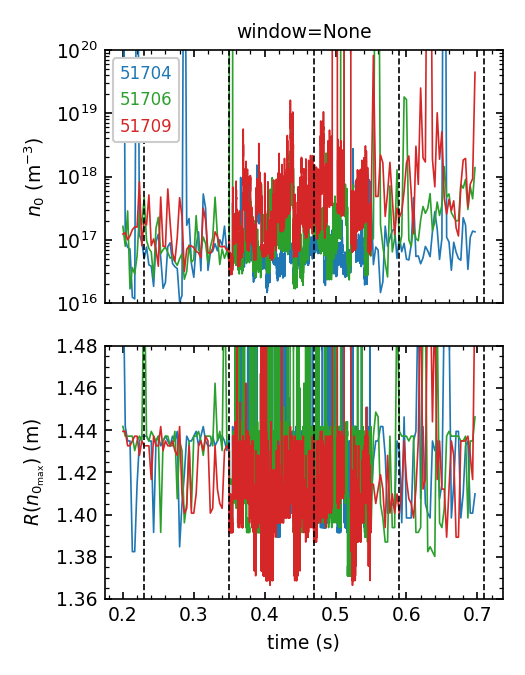

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        ax[0].plot(time[i], n0Max[i], c=f'C{i}', lw=0.8, label=shotn)
        ax[1].plot(time[i], n0MaxR[i], c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)
ax[0].set_title('window=None', fontsize=9)
ax[0].set_yscale('log')
ax[0].set_ylim([1e16,1e20])


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(n_{0_\\mathrm{max}})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.48])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

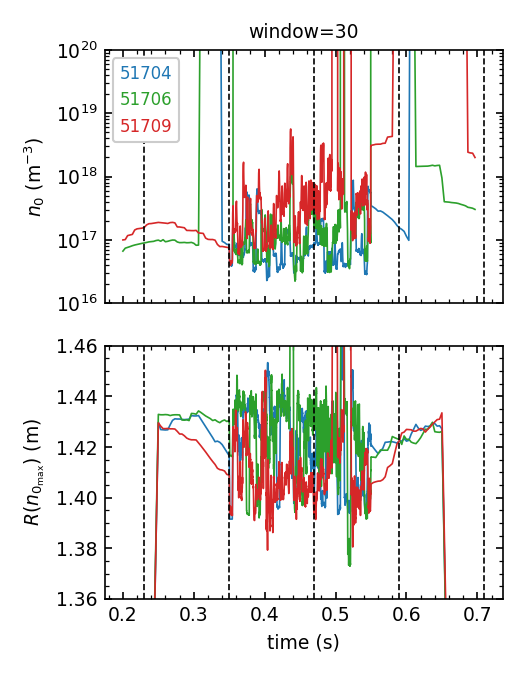

In [7]:
w = 30
n0MaxAverage = np.zeros_like(n0Max)
n0MaxRAverage = np.zeros_like(n0MaxR)
for i in range(0, len(shotns)):
    n0MaxAverage[i] = rolling(n0Max[i], w)
    n0MaxRAverage[i] = rolling(n0MaxR[i], w)
    

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        ax[0].plot(time[i], n0MaxAverage[i], c=f'C{i}', lw=0.8, label=shotn)
        ax[1].plot(time[i], n0MaxRAverage[i], c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel('$n_0$ (m$^{-3}$)', fontsize=9)
ax[0].set_title(f'window={w}', fontsize=9)
ax[0].set_yscale('log')
ax[0].set_ylim([1e16,1e20])


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel('$R(n_{0_\\mathrm{max}})$ (m)', fontsize=9)
ax[1].set_ylim([1.36, 1.46])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

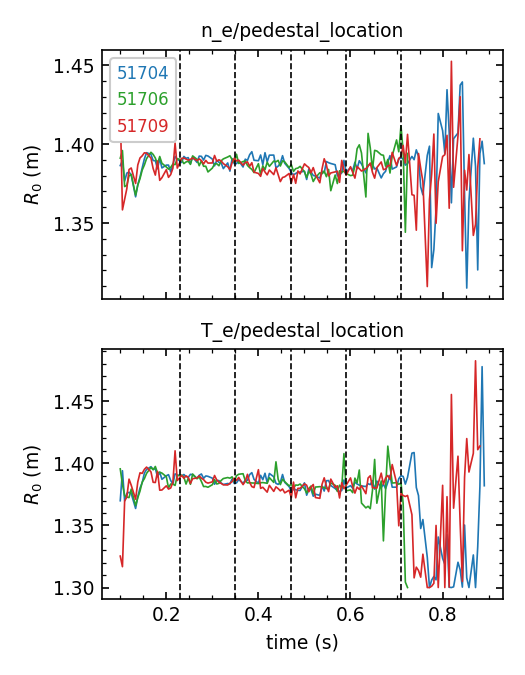

In [8]:
dataString0 = 'n_e/pedestal_location'
ylabel0 = '$R_0$ (m)'
dataString1 = 'T_e/pedestal_location'
ylabel1 = '$R_0$ (m)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

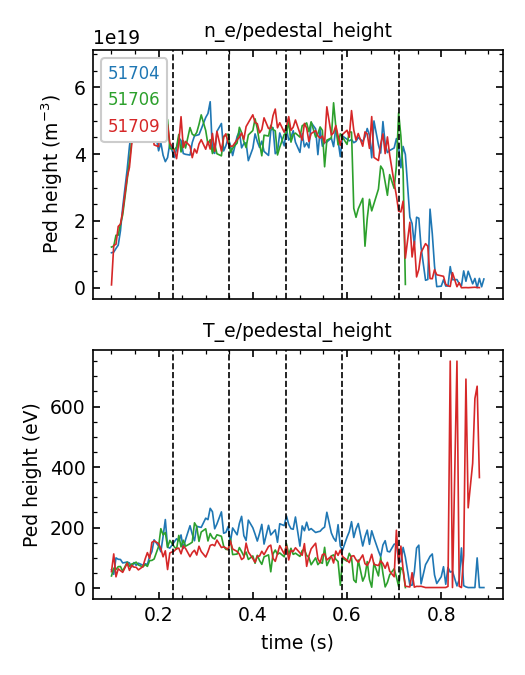

In [9]:
dataString0 = 'n_e/pedestal_height'
ylabel0 = 'Ped height (m$^{-3}$)'
dataString1 = 'T_e/pedestal_height'
ylabel1 = 'Ped height (eV)'

fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

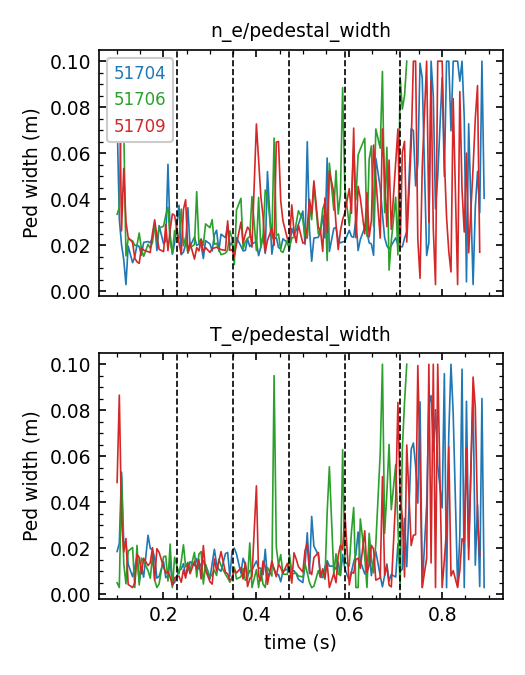

In [10]:
dataString0 = 'n_e/pedestal_width'
ylabel0 = 'Ped width (m)'
dataString1 = 'T_e/pedestal_width'
ylabel1 = 'Ped width (m)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

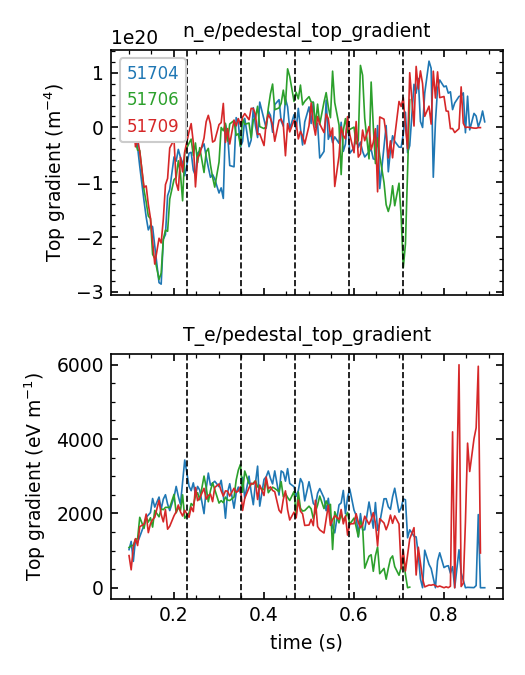

In [11]:
dataString0 = 'n_e/pedestal_top_gradient'
ylabel0 = 'Top gradient (m$^{-4}$)'
dataString1 = 'T_e/pedestal_top_gradient'
ylabel1 = 'Top gradient (eV m$^{-1}$)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

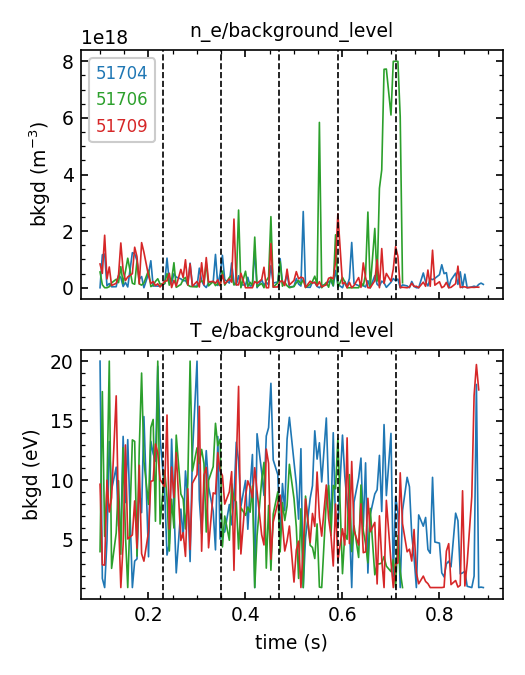

In [12]:
dataString0 = 'n_e/background_level'
ylabel0 = 'bkgd (m$^{-3}$)'
dataString1 = 'T_e/background_level'
ylabel1 = 'bkgd (eV)'


fig, ax = plt.subplots(2, 1, figsize=(3.5,4.5), dpi=150, sharex=True)


for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString0}', shotn).data
        ax[0].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
# ax[0].set_xlabel('time (s)', fontsize=9)
ax[0].set_ylabel(ylabel0, fontsize=9)
ax[0].set_title(f'{dataString0}', fontsize=9)

for i, shotn in enumerate(shotns):
    if boo[i]:
        timeThomson = client.get('/apf/core/mtanh/lfs/time', shotn).data
        R0 = client.get(f'/apf/core/mtanh/lfs/{dataString1}', shotn).data
        ax[1].plot(timeThomson, R0, c=f'C{i}', lw=0.8, label=shotn)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_xlabel('time (s)', fontsize=9)
ax[1].set_ylabel(ylabel1, fontsize=9)
ax[1].set_title(f'{dataString1}', fontsize=9)

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

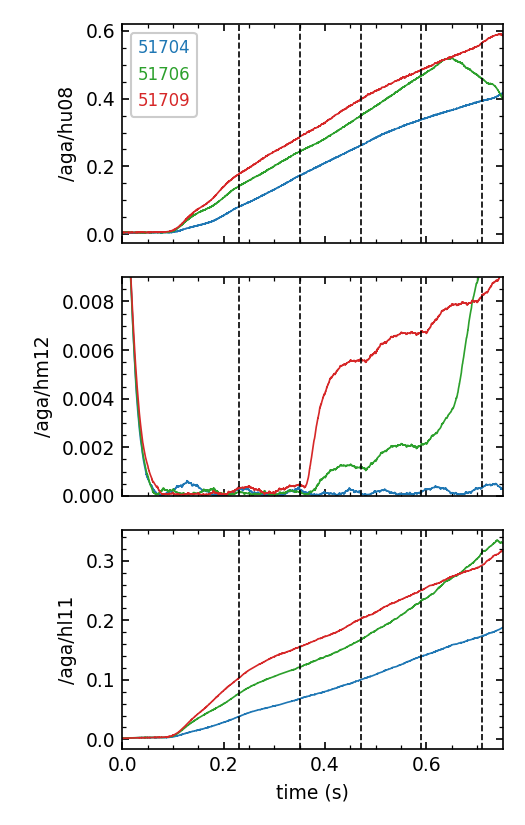

In [13]:
figUpper = '/aga/hu08'
figMid = '/aga/hm12'
figLower = '/aga/hl11'

fig, ax = plt.subplots(3, 1, figsize=(3.5,5.5), dpi=150, sharex=True)

for i, shotn in enumerate(shotns):
    if boo[i]:
        figU = client.get('/aga/hu08', shotn)
        ax[0].plot(figU.time.data, figU.data, c=f'C{i}', lw=0.8, label=shotn)
        figM = client.get('/aga/hm12', shotn)
        ax[1].plot(figM.time.data, figM.data, c=f'C{i}', lw=0.8, label=shotn)
        figL = client.get('/aga/hl11', shotn)
        ax[2].plot(figL.time.data, figL.data, c=f'C{i}', lw=0.8, label=shotn)
        

ax[0].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper left', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].minorticks_on()
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_ylabel(figUpper, fontsize=9)


ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].minorticks_on()
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_ylabel(figMid, fontsize=9)


ax[2].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[2].minorticks_on()
ax[2].yaxis.get_offset_text().set_size(9)
ax[2].set_xlabel('time (s)', fontsize=9)
ax[2].set_ylabel(figLower, fontsize=9)

ax[0].set_xlim([0.0, 0.75])
ax[1].set_ylim([0, 0.009])

for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')

plt.tight_layout()

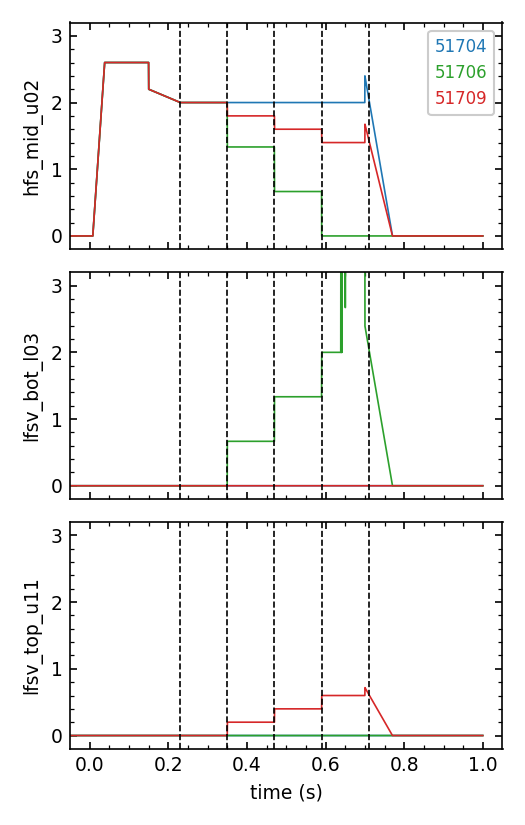

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(3.5,5.5), dpi=150, sharex=True)

I = 0
II = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II].plot(d.time.data, d.data, c=f'C{i}', lw=0.8, label=shotn)

ax[II].legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper right', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax[II].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II].minorticks_on()
ax[II].yaxis.get_offset_text().set_size(9)
ax[II].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II].set_ylim([-0.2, 3.2])


I = 1
II = 1
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II].plot(d.time.data, d.data, c=f'C{i}', lw=0.8, label=shotn)

ax[II].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II].minorticks_on()
ax[II].yaxis.get_offset_text().set_size(9)
ax[II].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II].set_ylim([-0.2, 3.2])


I = 2
II = 2
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(fuels[I], shotn)
        ax[II].plot(d.time.data, d.data, c=f'C{i}', lw=0.8, label=shotn)

ax[II].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[II].minorticks_on()
ax[II].yaxis.get_offset_text().set_size(9)
ax[II].set_ylabel(fuels[I].split('/')[-1], fontsize=9)
ax[II].set_xlabel('time (s)', fontsize=9)
ax[II].set_xlim([-0.05,1.05])
ax[II].set_ylim([-0.2, 3.2])


for AX in ax:
    ylim = AX.get_ylim()
    AX.set_ylim(ylim)
    AX.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')


plt.tight_layout()

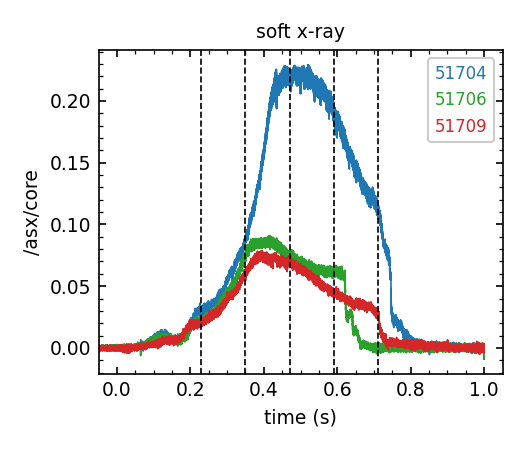

In [15]:
sxr = '/asx/core'

fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150, sharex=True)

I = 0
for i, shotn in enumerate(shotns):
    if boo[i]:
        d = client.get(sxr, shotn)
        ax.plot(d.time.data, d.data, c=f'C{i}', lw=0.8, label=shotn)

ax.legend(
    fancybox=1, framealpha=1, handlelength=0, loc='upper right', 
    handletextpad=0, labelcolor='linecolor', fontsize=8, 
)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_ylabel(sxr, fontsize=9)
ax.set_xlabel('time (s)', fontsize=9)
ax.set_xlim([-0.05,1.05])
# ax.set_ylim([-0.2, 3.2])
ax.set_title('soft x-ray', fontsize=9)


ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.vlines(puffs, ylim[0], ylim[1], colors='k', linewidths=0.8, linestyles='--')


plt.tight_layout()